In [1]:
import sys
sys.path.append('../../')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap,
                receptor_distances,
                full_array_entropy,
                mean_receptor_distance,
                mutual_information_family,
                mutual_information_concentration,
                rank_ordered_distances,
                mean_specialization_index,
                receptor_conditioned_entropy
                )
from run import initialize,train,test
from src.IO import ExperimentLogger
temp_ramp = lambda start,end,tmax,t:end + (start - end) * np.exp(-5.0 * t / tmax)
def p_open(c_reshaped: torch.Tensor,temperature):
        
        # Match dimensions: (Batch, 1, 1) -> (Batch, 1) to broadcast smoothly over R
        ln_c = torch.log(c_reshaped + 1e-12).squeeze(-1) 
        
        # Temperature-Scaled Binary Activation
        return torch.sigmoid((ln_c) / temperature)

1024
2048


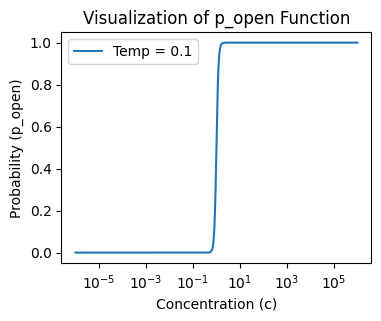

In [24]:
n_units_list = [5]#np.arange(1,15,1)#, 10, 15, 20, 30, 50]
print(2**10)
n_units = n_units_list[0]
k_sub = 5
n_families = 1
N_train = 2**11
print(N_train)
d =5

CONF = {
    # environment
        # energies
    "n_families": n_families,
    "latent_dim":d,
    "average_family_distance":.75, # distance  between the family centers
        # concentration
    "init_means": [np.random.randint(3, 5) for _ in range(n_families)], # Fixed 
    "shape_sigma": .1,#1./n_families,
    "use_sensitivity": False, # Set to False to remove sensitivity 
    # receptor 
    "k_sub": k_sub, # number of sub-units
    "temperature": .1, # temperature of the sigmoid that approximate a binary answer
    "n_units" : n_units, # number of genes
    "receptor_indices" : torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long), # actual receptors considered
    
    # training characteristics
    "batch_size": N_train,
    "epochs": 5000,


    "lr": 0.01, # learning rate
    "loss": "exact", # type of loss
    'entropy':'renyi',
    #"cov_weight":20.,
    "use_scheduler":True,
}

# 2. Create input data (c) 
# We use a range from 0.01 to 10 to see the logarithmic growth
c_values = torch.logspace(-6, 6, steps=500).view(-1, 1, 1)

# 3. Calculate outputs
with torch.no_grad():
    y_values = p_open(c_values, CONF['temperature'])

# 4. Plotting
plt.figure(figsize=(4, 3))
# We convert to numpy for matplotlib and flatten the dimensions
plt.plot(c_values.view(-1).numpy(), y_values.view(-1).numpy(), label=f'Temp = {CONF["temperature"]}')

plt.title("Visualization of p_open Function")
plt.xlabel("Concentration (c)")
plt.ylabel("Probability (p_open)")
plt.xscale('log')
plt.legend()
plt.show()

Fitting UMAP... (This may take a few seconds)


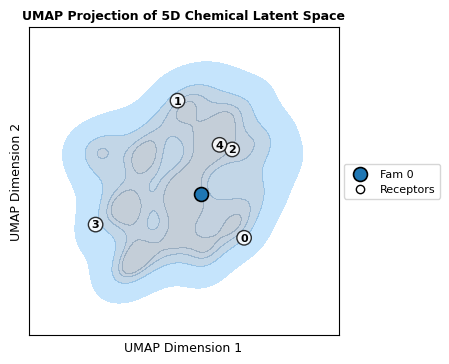

In [12]:
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])
#fig.savefig('3fam_5rec_pre_opt.svg',bbox_inches='tight')

In [13]:
#fig.savefig('umap_5fam_5receptors.svg',bbox_inches='tight')

In [25]:
prev_env = None
train_out = list()
#fig,ax = plt.subplots(ncols=2,figsize=(6,3))

for n_units in n_units_list: # e.g., [1, 2, 3, 4, 5, ...]
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    # Pass prev_env to start from the n-1 endpoint
    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False, prev_env=prev_env)
    
    train_out.append(train(CONF, env, rec, loss_fn, optimize, measurement_fns=[full_array_entropy, 
                                                                                mean_receptor_distance,
                                                                                mutual_information_family,
                                                                                mutual_information_concentration,
                                                                                rank_ordered_distances,
                                                                                mean_specialization_index,
                                                                                receptor_conditioned_entropy]))
    
    # Save the current environment to be the foundation for the next iteration
    prev_env = env
    




--- Starting training for n_units = 5 ---
Training for 5000 epochs...
0.1


In [6]:
train_out[0].keys()

dict_keys(['full_array_entropy', 'mean_receptor_distance', 'mutual_information_family', 'mutual_information_concentration', 'dist_rank_1', 'dist_rank_2', 'dist_rank_3', 'dist_rank_4', 'dist_rank_5', 'dist_rank_6', 'dist_rank_7', 'dist_rank_8', 'dist_rank_9', 'dist_rank_10', 'mean_specialization_index', 'receptor_conditioned_entropy', 'lr'])

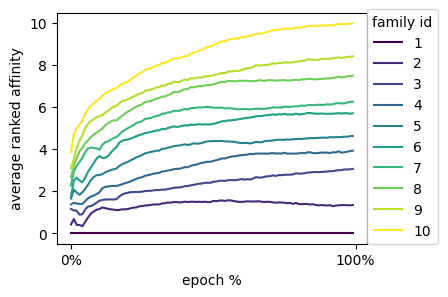

In [7]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(ncols=1, figsize=(4, 3))

# Define the number of lines
n_lines = 10

for i in range(1, n_lines + 1):
    # Normalize i to the range [0, 1] for the colormap
    # Using (i-1)/(n_lines-1) ensures the first is dark purple and the last is bright yellow
    color = cm.viridis((i - 1) / (n_lines - 1))
    
    ax.plot(train_out[0]['dist_rank_' + str(i)], 
            label=f'{i}', 
            color=color)
ax.set_xlabel('epoch %')
ax.set_xticks([0,100],['0%','100%'])
ax.set_ylabel('average ranked affinity')
ax.legend(title='family id',loc=(1,0))
plt.savefig('average_affinity.svg',bbox_inches='tight')

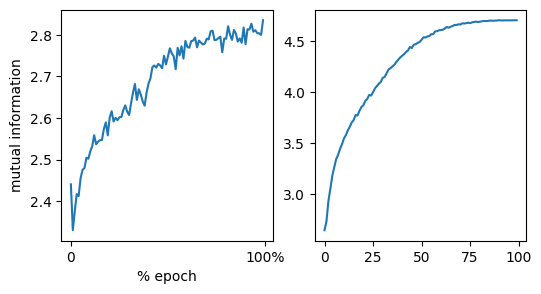

In [26]:
fig,ax = plt.subplots(ncols=2,figsize=(6,3))
ax[0].plot(train_out[-1]['full_array_entropy'])
ax[0].set_xlabel('% epoch')
ax[0].set_xticks([0,100],['0','100%'])
ax[0].set_ylabel('mutual information')
ax[1].plot(train_out[-1]['mean_receptor_distance'])
fig.show()

In [ ]:
ax.plot(train_out[-1]['full_array_entropy'])
ax.set_xlabel('% epoch')
ax.set_xticks([0,100],['0','100%'])
ax.set_ylabel('mutual information')
#fig.savefig('mi_opti.svg')

Fitting UMAP... (This may take a few seconds)


Text(0.5, 1.0, '')

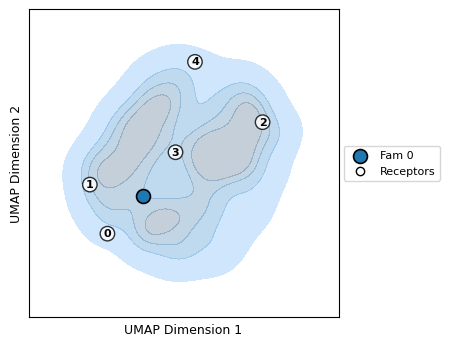

In [16]:
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])
ax.set_title('')
#fig.savefig('10fam_5rec_post_opt_5D-dist0_75.png',bbox_inches='tight',dpi=500)

(<Figure size 500x400 with 1 Axes>, <PolarAxes: >)

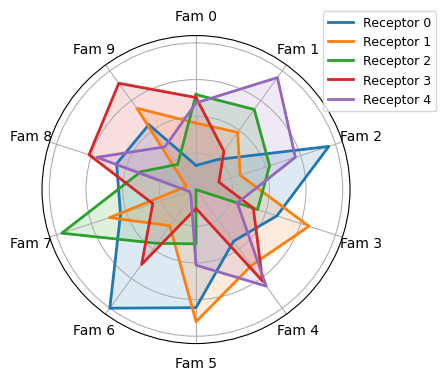

In [10]:
plot_latent_radar_chart(env, CONF['receptor_indices'])
#plt.savefig('radar_chart_5D_dist0_75.svg',bbox_inches='tight')

In [58]:
with torch.no_grad():
    u_e = env.unit_latent.cpu()
    r_e = u_e[CONF['receptor_indices']].mean(dim=1).numpy()
    f_e = env.family_latent.cpu().numpy()
    b_e = env.base_energy_u.cpu().numpy()

    print(np.linalg.norm(f_e-r_e[0],axis=1))
    #print(np.sum((f_e - r_e[0])**2,axis=1)+b_e)
    print(env.interaction_mu[0])


[4.2208385 4.5011067 5.6742435 4.747199  6.3587594 4.6770735 4.267073
 3.1598306 3.9760358 3.725512 ]
tensor([ 5.2248,  7.6692, 19.6063,  9.9452, 27.8431,  9.2843,  5.6172, -2.6062,
         3.2181,  1.2887], device='cuda:0')


In [ ]:
unit_energies = env.interaction_mu.cpu()


tensor([[0.5413, 0.5413, 0.5413, 0.5413, 0.5413],
        [0.5413, 0.5413, 0.5413, 0.5413, 0.5413],
        [0.5413, 0.5413, 0.5413, 0.5413, 0.5413],
        [0.5413, 0.5413, 0.5413, 0.5413, 0.5413],
        [0.5413, 0.5413, 0.5413, 0.5413, 0.5413]], device='cuda:0')


--- Starting training for n_units = 20 ---
Training for 5000 epochs...
0.1


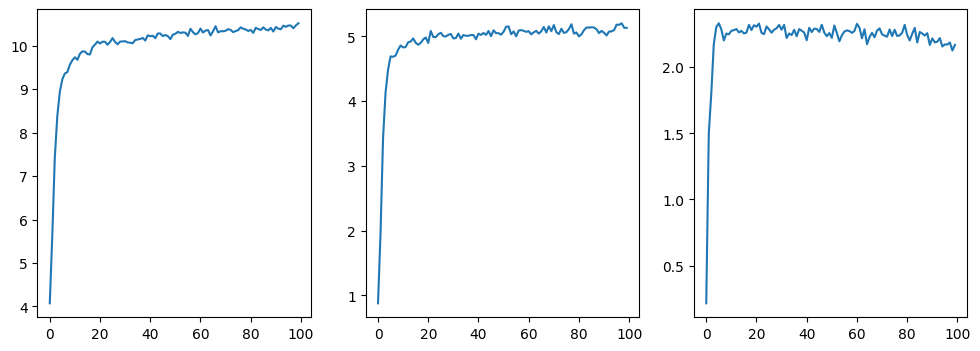

In [47]:
prev_env = None
train_out = list()
fig,ax = plt.subplots(ncols=3,figsize=(12,4))

for n_units in n_units_list: # e.g., [1, 2, 3, 4, 5, ...]
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    # Pass prev_env to start from the n-1 endpoint
    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False, prev_env=prev_env)
    
    train_out.append(train(CONF, env, rec, loss_fn, optimize, measurement_fns=[full_array_entropy, mean_receptor_distance,mutual_information_family,mutual_information_concentration]))
    
    # Save the current environment to be the foundation for the next iteration
    prev_env = env
    
    ax[0].plot(train_out[-1]['full_array_entropy'])
    ax[1].plot(train_out[-1]['mutual_information_family'])
    ax[2].plot(train_out[-1]['mutual_information_concentration'])


In [5]:
for n_units in n_units_list:
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
    
    print(env.base_energy_u)

    train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])


--- Starting training for n_units = 10 ---
Parameter containing:
tensor([-1431.5188, -1431.5188, -1431.5188, -1431.5188, -1431.5188, -1431.5188,
        -1431.5188, -1431.5188, -1431.5188, -1431.5188], device='cuda:0',
       requires_grad=True)
Training for 50000 epochs...
0.01
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_294935/4145326198.py", line 11, in <module>
    train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])
  File "/app/run/notebooks/../../run/run.py", line 157, in train
  File "/usr/local/lib/python3.10/dist-packages/torch/_tensor.py", line 503, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.10/dist-packages/torch/autograd/__init__.py", line 254, in backward
    Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 2144, in showtraceback
    s

(0.0, 10.0)

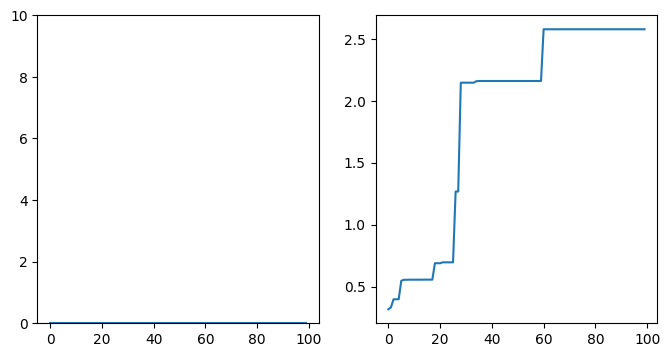

In [ ]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])
#ax[0].set_ylim(0,10)

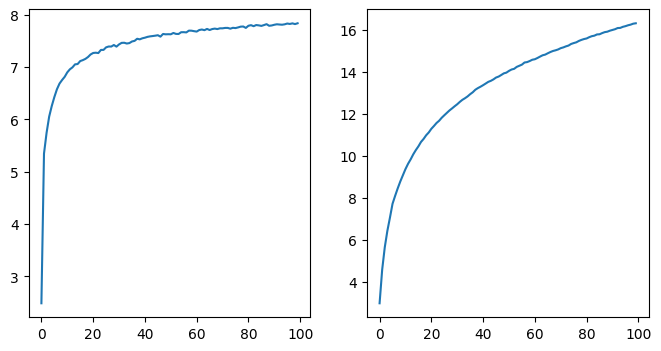

In [49]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])

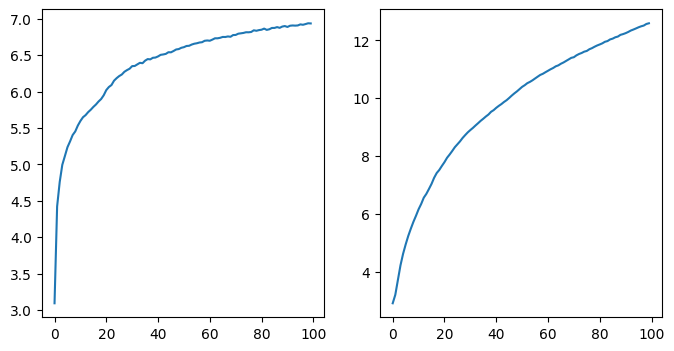

In [36]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])

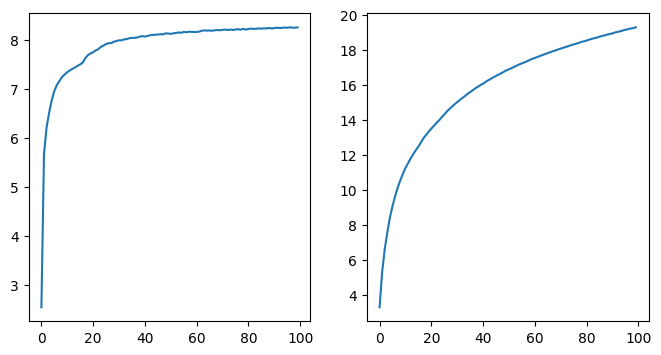

In [30]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])

Fitting UMAP... (This may take a few seconds)


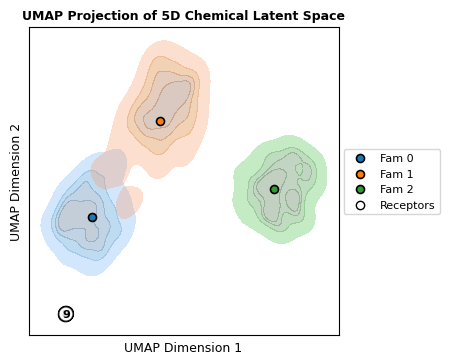

In [47]:
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])

(<Figure size 400x300 with 3 Axes>,
 (<Axes: title={'center': 'Global Receptor Array Binary Response'}, ylabel='Activity Probability $p(a=1)$'>,
  <Axes: xlabel='Concentration (M)', ylabel='p(c)'>,
  <Axes: xlabel='Global Mass'>))

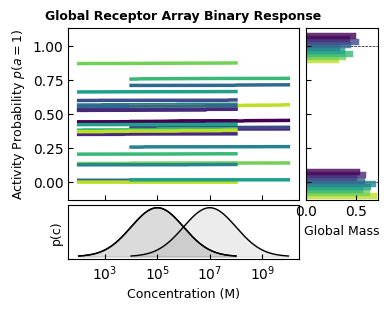

In [6]:
plot_summary(env,rec,CONF['receptor_indices'],loss_fn=loss_fn)